# moteurs_recherche_demo.ipynb

In [1]:
# notebooks/moteurs_recherche_demo.ipynb
# ─────────────────────────────────────────────────────────────
# CELLULE 1 — Setup et imports
# ─────────────────────────────────────────────────────────────

import sys
from pathlib import Path
import warnings
import time
warnings.filterwarnings("ignore")

RACINE = Path("..").resolve()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from elasticsearch import Elasticsearch
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv(RACINE / ".env")
print("Imports OK")

Imports OK


In [2]:
# ─────────────────────────────────────────────────────────────
# CELLULE 2 — Connexions
# ─────────────────────────────────────────────────────────────

# Elasticsearch
es = Elasticsearch(
    f"http://{os.getenv('ELASTIC_HOST', 'localhost')}:"
    f"{os.getenv('ELASTIC_PORT', 9200)}"
)
assert es.ping(), "Elasticsearch inaccessible"
print(f"ES connecté — {es.count(index='offres')['count']} documents")

# PostgreSQL
conn = psycopg2.connect(
    host     = os.getenv("POSTGRES_HOST", "localhost"),
    port     = int(os.getenv("POSTGRES_PORT", 5432)),
    dbname   = os.getenv("POSTGRES_DB", "job_market"),
    user     = os.getenv("POSTGRES_USER"),
    password = os.getenv("POSTGRES_PASSWORD"),
)
print("PostgreSQL connecté")

ES connecté — 9079 documents
PostgreSQL connecté


In [3]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3 — Chargement des offres
# ─────────────────────────────────────────────────────────────

df = pd.read_sql("""
    SELECT
        o.id,
        o.titre,
        o.description,
        o.localisation_ville,
        o.type_contrat,
        o.salaire_min,
        o.salaire_max,
        o.source,
        STRING_AGG(DISTINCT c.competence, ' ') AS competences
    FROM offres o
    LEFT JOIN competences c ON c.offre_id = o.id
    GROUP BY
        o.id, o.titre, o.description,
        o.localisation_ville, o.type_contrat,
        o.salaire_min, o.salaire_max, o.source
""", conn)

# Nettoyer
df["titre"]       = df["titre"].fillna("")
df["description"] = df["description"].fillna("")
df["competences"] = df["competences"].fillna("")

# Champ texte unifié pour TF-IDF et ST
# Le titre est doublé — même logique que ES avec titre^2
df["texte"] = (
    df["titre"]       + " " +
    df["titre"]       + " " +
    df["description"] + " " +
    df["competences"]
)

print(f"{len(df)} offres chargées")
df[["id", "titre", "localisation_ville", "type_contrat"]].head()

8592 offres chargées


,id,titre,localisation_ville,type_contrat
0,ft_0009936,Data scientist,Paris,CDI
1,ft_0010289,Data manager,Luxembourg,CDI
2,ft_0019264,Ingénieur / Ingénieure bases de données,Brest,CDI
3,ft_0019320,Data manager,Paris 9E Arrondissement,CDI
4,ft_0020076,Développeur(se) décisionnel - Business Intelli...,Rhône,CDI


In [4]:
# ─────────────────────────────────────────────────────────────
# CELLULE 4 — Initialisation des moteurs
# ─────────────────────────────────────────────────────────────

NB_RESULTATS = 10  # nombre de résultats à afficher

# ── Moteur 1 : TF-IDF ─────────────────────────────────────────
print("Initialisation TF-IDF...")
debut   = time.perf_counter()
tfidf   = TfidfVectorizer(
    max_features = 10000,
    ngram_range  = (1, 2),   # unigrammes et bigrammes
    sublinear_tf = True,      # atténue l'effet des mots très fréquents
)
display(tfidf)

X_tfidf = tfidf.fit_transform(df["texte"])
print(f"  Matrice TF-IDF : {X_tfidf.shape}")
print(f"  Temps          : {(time.perf_counter()-debut)*1000:.0f}ms\n")

display(X_tfidf)

# ── Moteur 2 : Sentence Transformers ──────────────────────────
print("Initialisation Sentence Transformers...")
print("  Chargement du modèle multilingue...")
debut    = time.perf_counter()
model_st = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

print("  Calcul des embeddings (peut prendre quelques minutes)...")
embeddings_offres = model_st.encode(
    df["texte"].tolist(),
    batch_size        = 64,
    show_progress_bar = True,
)
print(f"  Embeddings : {embeddings_offres.shape}")
print(f"  Temps      : {(time.perf_counter()-debut)*1000:.0f}ms\n")

print("Elasticsearch — prêt (pas d'initialisation nécessaire)\n")
print("Tous les moteurs initialisés.")

Initialisation TF-IDF...


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

  Matrice TF-IDF : (8592, 10000)
  Temps          : 6646ms



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2908322 stored elements and shape (8592, 10000)>

Initialisation Sentence Transformers...
  Chargement du modèle multilingue...


Loading weights: 100%|█| 199/199 [00:00<00:00, 


  Calcul des embeddings (peut prendre quelques minutes)...


Batches: 100%|█| 135/135 [24:26<00:00, 10.86s/i

  Embeddings : (8592, 768)
  Temps      : 1427509ms

Elasticsearch — prêt (pas d'initialisation nécessaire)

Tous les moteurs initialisés.


In [5]:
# ─────────────────────────────────────────────────────────────
# CELLULE 5 — Fonctions de recherche
# ─────────────────────────────────────────────────────────────

def afficher_resultats(titre_moteur: str, resultats: list, temps_ms: float):
    """Affiche les résultats de façon lisible."""
    print(f"\n{'═' * 60}")
    print(f"  {titre_moteur}")
    print(f"  Temps : {temps_ms:.1f}ms")
    print(f"{'═' * 60}")
    for i, r in enumerate(resultats, start=1):
        salaire = ""
        if r.get("salaire_min"):
            salaire = f" | {r['salaire_min']:,}€"
            if r.get("salaire_max"):
                salaire += f" - {r['salaire_max']:,}€"
        print(
            f"  {i:2}. {r['titre'][:50]:<50}"
            f"  {(r.get('localisation_ville') or 'N/A'):<15}"
            f"  {(r.get('type_contrat') or 'N/A'):<10}"
            f"{salaire}"
        )


def rechercher_tfidf(requete: str, n: int = NB_RESULTATS) -> tuple:
    """
    Moteur 1 — TF-IDF + Similarité cosinus.

    Étapes :
        1. Vectoriser la requête avec le même TF-IDF
        2. Calculer la similarité cosinus entre la requête et toutes les offres
        3. Retourner les n offres avec le score le plus élevé
    """
    debut      = time.perf_counter()
    x_requete  = tfidf.transform([requete])
    scores     = cosine_similarity(x_requete, X_tfidf).flatten()
    indices    = scores.argsort()[-n:][::-1]
    temps_ms   = (time.perf_counter() - debut) * 1000

    resultats = df.iloc[indices][[
        "id", "titre", "localisation_ville", "type_contrat",
        "salaire_min", "salaire_max"
    ]].to_dict("records")

    # Ajouter le score à chaque résultat
    for j, r in enumerate(resultats):
        r["score"] = round(float(scores[indices[j]]), 4)

    return resultats, temps_ms


def rechercher_st(requete: str, n: int = NB_RESULTATS) -> tuple:
    """
    Moteur 2 — Sentence Transformers + Similarité cosinus.

    Étapes :
        1. Encoder la requête avec le modèle ST
        2. Calculer la similarité cosinus avec les embeddings précalculés
        3. Retourner les n offres les plus proches sémantiquement
    """
    debut         = time.perf_counter()
    emb_requete   = model_st.encode([requete])
    scores        = cosine_similarity(emb_requete, embeddings_offres).flatten()
    indices       = scores.argsort()[-n:][::-1]
    temps_ms      = (time.perf_counter() - debut) * 1000

    resultats = df.iloc[indices][[
        "id", "titre", "localisation_ville", "type_contrat",
        "salaire_min", "salaire_max"
    ]].to_dict("records")

    for j, r in enumerate(resultats):
        r["score"] = round(float(scores[indices[j]]), 4)

    return resultats, temps_ms


def rechercher_es(requete: str, n: int = NB_RESULTATS) -> tuple:
    """
    Moteur 3 — Elasticsearch BM25.

    Étapes :
        1. Envoyer la requête à ES via multi_match
        2. ES calcule le score BM25 sur titre, description, compétences
        3. Retourner les n résultats les mieux scorés
    """
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": n,
    }

    debut    = time.perf_counter()
    res      = es.search(index="offres", body=body)
    temps_ms = (time.perf_counter() - debut) * 1000

    resultats = []
    for hit in res["hits"]["hits"]:
        src = hit["_source"]
        resultats.append({
            "id":                hit["_id"],
            "titre":             src.get("titre", ""),
            "localisation_ville":src.get("localisation_ville", ""),
            "type_contrat":      src.get("type_contrat", ""),
            "salaire_min":       src.get("salaire_min"),
            "salaire_max":       src.get("salaire_max"),
            "score":             round(hit["_score"], 4),
        })

    return resultats, temps_ms


def rechercher_retrieve_rerank(
    requete:     str,
    n:           int = NB_RESULTATS,
    top_k_es:    int = 50,
) -> tuple:
    """
    Moteur 4 — Retrieve & Rerank (ES + Sentence Transformers).

    Étapes :
        1. ES récupère les top_k_es candidats (vitesse)
        2. ST reclasse ces candidats par similarité sémantique (précision)
        3. Retourner les n meilleurs après reclassement

    Avantage : ST ne calcule la similarité que sur top_k_es offres
    au lieu de tout le corpus — beaucoup plus rapide que ST seul.
    """
    debut = time.perf_counter()

    # ── Étape 1 : Retrieve (ES) ───────────────────────────────
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": top_k_es,
    }
    res_es        = es.search(index="offres", body=body)
    ids_candidats = [h["_id"] for h in res_es["hits"]["hits"]]

    if not ids_candidats:
        return [], (time.perf_counter() - debut) * 1000

    # ── Étape 2 : Rerank (ST) ─────────────────────────────────
    # Trouver les indices des candidats dans df
    masque      = df["id"].isin(ids_candidats)
    idx_cand    = np.where(masque)[0]

    if len(idx_cand) == 0:
        return [], (time.perf_counter() - debut) * 1000

    # Utiliser les embeddings précalculés — pas de recalcul
    emb_requete = model_st.encode([requete])
    emb_cand    = embeddings_offres[idx_cand]
    scores_st   = cosine_similarity(emb_requete, emb_cand).flatten()

    # Trier par score ST décroissant
    top_idx   = scores_st.argsort()[-n:][::-1]
    idx_final = idx_cand[top_idx]

    temps_ms  = (time.perf_counter() - debut) * 1000

    resultats = df.iloc[idx_final][[
        "id", "titre", "localisation_ville", "type_contrat",
        "salaire_min", "salaire_max"
    ]].to_dict("records")

    for j, r in enumerate(resultats):
        r["score_es"] = round(float(scores_st[top_idx[j]]), 4)

    return resultats, temps_ms

print("Fonctions de recherche définies.")

Fonctions de recherche définies.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6 — Démo interactive
# ─────────────────────────────────────────────────────────────

# ── Modifie cette requête pour tester ─────────────────────────
REQUETE = "data engineer Python Paris CDI"
# ─────────────────────────────────────────────────────────────

print(f"Requête : '{REQUETE}'\n")

# TF-IDF
res_tfidf, t_tfidf = rechercher_tfidf(REQUETE)
afficher_resultats("TF-IDF + Similarité cosinus", res_tfidf, t_tfidf)

# Sentence Transformers
res_st, t_st = rechercher_st(REQUETE)
afficher_resultats("Sentence Transformers", res_st, t_st)

# Elasticsearch
res_es, t_es = rechercher_es(REQUETE)
afficher_resultats("Elasticsearch (BM25)", res_es, t_es)

# Retrieve & Rerank
res_rrk, t_rrk = rechercher_retrieve_rerank(REQUETE)
afficher_resultats("Retrieve & Rerank (ES + ST)", res_rrk, t_rrk)

# Résumé des temps
print(f"\n{'─' * 40}")
print(f"  Résumé des temps d'exécution")
print(f"{'─' * 40}")
print(f"  TF-IDF              : {t_tfidf:.1f} ms")
print(f"  Sentence Transformers: {t_st:.1f} ms")
print(f"  Elasticsearch       : {t_es:.1f} ms")
print(f"  Retrieve & Rerank   : {t_rrk:.1f} ms")

Requête : 'data engineer Python Paris CDI'


════════════════════════════════════════════════════════════
  TF-IDF + Similarité cosinus
  Temps : 145.0ms
════════════════════════════════════════════════════════════
   1. Data Engineer                                       London           CDI        | nan€ - nan€
   2. Data Engineer                                       Paris            CDI        | nan€ - nan€
   3. Data Engineer                                       London           CDI        | nan€ - nan€
   4. Data Engineer H/F                                   Villeurbanne     CDI        | nan€ - nan€
   5. Senior Data Engineer                                nan              CDI        | nan€ - nan€
   6. Data Engineer Microsoft Fabric et Azure (CDI - H/F  Toulouse         CDI        | nan€ - nan€
   7. Data engineer                                       Puteaux          CDI        | 50,000.0€ - 60,000.0€
   8. Stage - Data Engineer                               Paris            

In [7]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7 — Comparaison côte à côte
# ─────────────────────────────────────────────────────────────

def comparer_moteurs(requete: str, n: int = 5):
    """
    Compare les résultats des 4 moteurs côte à côte
    sous forme de DataFrame.
    """
    res_tf,  _ = rechercher_tfidf(requete, n)
    res_st,  _ = rechercher_st(requete, n)
    res_es,  _ = rechercher_es(requete, n)
    res_rrk, _ = rechercher_retrieve_rerank(requete, n)

    # Construire le tableau comparatif
    df_comp = pd.DataFrame({
        "Rang":       range(1, n + 1),
        "TF-IDF":     [r["titre"][:35] for r in res_tf],
        "ST":         [r["titre"][:35] for r in res_st],
        "ES":         [r["titre"][:35] for r in res_es],
        "R&R":        [r["titre"][:35] for r in res_rrk],
    }).set_index("Rang")

    print(f"\nComparaison — Requête : '{requete}'\n")
    print(df_comp.to_string())

    # Chevauchement entre les moteurs
    ids_tf  = set(r["id"] for r in res_tf)
    ids_st  = set(r["id"] for r in res_st)
    ids_es  = set(r["id"] for r in res_es)
    ids_rrk = set(r["id"] for r in res_rrk)

    print(f"\n  Chevauchement TF-IDF / ES    : {len(ids_tf & ids_es)}/{n} offres communes")
    print(f"  Chevauchement ST / ES         : {len(ids_st & ids_es)}/{n} offres communes")
    print(f"  Chevauchement R&R / ES        : {len(ids_rrk & ids_es)}/{n} offres communes")
    print(f"  Chevauchement TF-IDF / ST     : {len(ids_tf & ids_st)}/{n} offres communes")

    return df_comp


# Tester avec plusieurs requêtes
for requete in [
    "data engineer Python Paris",
    "machine learning tensorflow",
    "chef de projet agile",
]:
    comparer_moteurs(requete, n=5)
    print()


Comparaison — Requête : 'data engineer Python Paris'

                    TF-IDF                                   ST                                   ES                                  R&R
Rang                                                                                                                                     
1            Data Engineer                       Data scientist            Software Engineer- Python                        Data engineer
2            Data Engineer  Data Engineer Confirmé(e) - expert                     Big data engineer  Stage - Consultant Data / IAG Ingén
3            Data Engineer                        Data engineer                        Data engineer                        Data engineer
4        Data Engineer H/F                        Data engineer  Ingénieur / Ingénieure en développe                        Data engineer
5     Senior Data Engineer                        Data engineer                        Data engineer                 

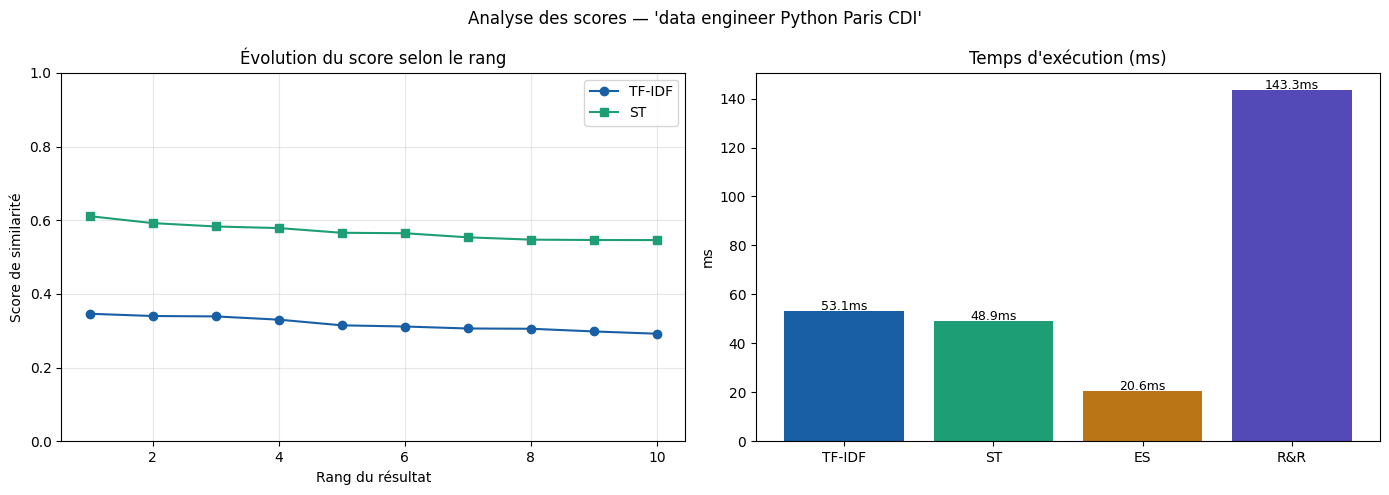

In [8]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8 — Analyse des scores
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

def visualiser_scores(requete: str, n: int = 10):
    """
    Visualise et compare les scores des 4 moteurs
    pour une requête donnée.
    """
    res_tf,  t_tf  = rechercher_tfidf(requete, n)
    res_st,  t_st  = rechercher_st(requete, n)
    res_es,  t_es  = rechercher_es(requete, n)
    res_rrk, t_rrk = rechercher_retrieve_rerank(requete, n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Analyse des scores — '{requete}'", fontsize=12)

    # ── Scores par moteur ─────────────────────────────────────
    moteurs = ["TF-IDF", "ST", "ES", "R&R"]
    temps   = [t_tf, t_st, t_es, t_rrk]
    couleurs = ["#185FA5", "#1D9E75", "#BA7517", "#534AB7"]

    # Distribution des scores TF-IDF et ST (entre 0 et 1)
    scores_tf  = [r["score"] for r in res_tf]
    scores_st  = [r["score"] for r in res_st]

    axes[0].plot(range(1, n+1), scores_tf, "o-",
                 label="TF-IDF", color="#185FA5")
    axes[0].plot(range(1, n+1), scores_st, "s-",
                 label="ST",     color="#1D9E75")
    axes[0].set_title("Évolution du score selon le rang")
    axes[0].set_xlabel("Rang du résultat")
    axes[0].set_ylabel("Score de similarité")
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Temps d'exécution
    axes[1].bar(moteurs, temps, color=couleurs)
    axes[1].set_title("Temps d'exécution (ms)")
    axes[1].set_ylabel("ms")
    for i, t in enumerate(temps):
        axes[1].text(i, t + 0.5, f"{t:.1f}ms", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()


visualiser_scores("data engineer Python Paris CDI")

In [9]:
# ─────────────────────────────────────────────────────────────
# CELLULE 9 — Requête libre interactive
# ─────────────────────────────────────────────────────────────

def rechercher_tous(requete: str, n: int = NB_RESULTATS):
    """
    Lance les 4 moteurs sur une requête et affiche tout.
    Fonction principale à utiliser pour explorer.
    """
    print(f"\n{'═'*60}")
    print(f"  REQUÊTE : '{requete}'")
    print(f"{'═'*60}")

    moteurs = {
        "TF-IDF + Cosinus":         rechercher_tfidf,
        "Sentence Transformers":    rechercher_st,
        "Elasticsearch (BM25)":     rechercher_es,
        "Retrieve & Rerank":        rechercher_retrieve_rerank,
    }

    temps_total = {}
    for nom, fn in moteurs.items():
        res, t = fn(requete, n)
        afficher_resultats(nom, res, t)
        temps_total[nom] = t

    print(f"\n{'─'*40}")
    print("  BILAN DES TEMPS")
    print(f"{'─'*40}")
    for nom, t in sorted(temps_total.items(), key=lambda x: x[1]):
        barre = "█" * int(t / 10)
        print(f"  {nom:<30} {t:7.1f}ms  {barre}")


# ── Teste ici ta propre requête ───────────────────────────────
rechercher_tous("data scientist machine learning Paris", n=5)


════════════════════════════════════════════════════════════
  REQUÊTE : 'data scientist machine learning Paris'
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  TF-IDF + Cosinus
  Temps : 64.4ms
════════════════════════════════════════════════════════════
   1. Apprenticeship - Digital Engineer - Data Scientist  Villeurbanne     CDI        | nan€ - nan€
   2. Data scientist                                      Paris            CDI        | 45,000.0€ - 65,000.0€
   3. Data scientist                                      Versailles       Mission intérimaire | nan€ - nan€
   4. Data scientist                                      Lyon             Mission intérimaire | nan€ - nan€
   5. Data scientist                                      Lille            Mission intérimaire | nan€ - nan€

════════════════════════════════════════════════════════════
  Sentence Transformers
  Temps : 57.6ms
══════════════════════════

In [10]:
# ─────────────────────────────────────────────────────────────
# CELLULE 10 — Nettoyage
# ─────────────────────────────────────────────────────────────

conn.close()
print("Connexions fermées.")
print("""
─────────────────────────────────────────────────────────────
RÉSUMÉ DES MOTEURS IMPLÉMENTÉS
─────────────────────────────────────────────────────────────

TF-IDF + Cosinus
    → Vectorise par fréquence de mots
    → Rapide, pas d'entraînement
    → Ne comprend pas le sens

Sentence Transformers
    → Encode le sens sémantique
    → Comprend les synonymes
    → Plus lent (calcul dense)

Elasticsearch
    → BM25 multi-champs pondérés
    → Standard production
    → Requête réseau

Retrieve & Rerank
    → ES sélectionne les candidats (vitesse)
    → ST reclasse par sens (précision)
    → Meilleur des deux mondes
─────────────────────────────────────────────────────────────
""")

Connexions fermées.

─────────────────────────────────────────────────────────────
RÉSUMÉ DES MOTEURS IMPLÉMENTÉS
─────────────────────────────────────────────────────────────

TF-IDF + Cosinus
    → Vectorise par fréquence de mots
    → Rapide, pas d'entraînement
    → Ne comprend pas le sens

Sentence Transformers
    → Encode le sens sémantique
    → Comprend les synonymes
    → Plus lent (calcul dense)

Elasticsearch
    → BM25 multi-champs pondérés
    → Standard production
    → Requête réseau

Retrieve & Rerank
    → ES sélectionne les candidats (vitesse)
    → ST reclasse par sens (précision)
    → Meilleur des deux mondes
─────────────────────────────────────────────────────────────

